# Optimización no convexa y mínimos locales

Este notebook estudia el problema

$$
\min_{x,y} f(x,y)
$$

usando una función de dos variables con varios mínimos. Los estudiantes podrán modificar aleatoriamente los parámetros y observar que el resultado depende del punto inicial.

## Objetivos

- Identificar variables de decisión y función objetivo.
- Diferenciar mínimo local y mínimo global.
- Explorar una superficie mediante curvas de nivel.
- Implementar una búsqueda aleatoria local.
- Analizar el efecto del punto inicial y del tamaño del paso.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(42)

## 1. Definición formal

Un problema de optimización busca los valores de unas variables de decisión que producen el mejor valor posible de una función objetivo.

$$
\min_{\boldsymbol{\theta}} J(\boldsymbol{\theta})
$$

En este caso,

$$
\boldsymbol{\theta}=
\begin{bmatrix}
x\\
y
\end{bmatrix}
$$

y queremos minimizar $f(x,y)$.

## 2. Función de Himmelblau

Usaremos

$$
f(x,y)=(x^2+y-11)^2+(x+y^2-7)^2.
$$

Es una función no convexa con cuatro mínimos. Por ello, un método local puede terminar en soluciones diferentes según el punto inicial.

In [2]:
def objective(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

known_minima = np.array([
    [3.000000, 2.000000],
    [-2.805118, 3.131312],
    [-3.779310, -3.283186],
    [3.584428, -1.848126],
])

for p in known_minima:
    print(p, "->", objective(*p))

[3. 2.] -> 0.0
[-2.805118  3.131312] -> 1.0989296656869089e-11
[-3.77931  -3.283186] -> 3.797861082863832e-12
[ 3.584428 -1.848126] -> 8.894376497582423e-12


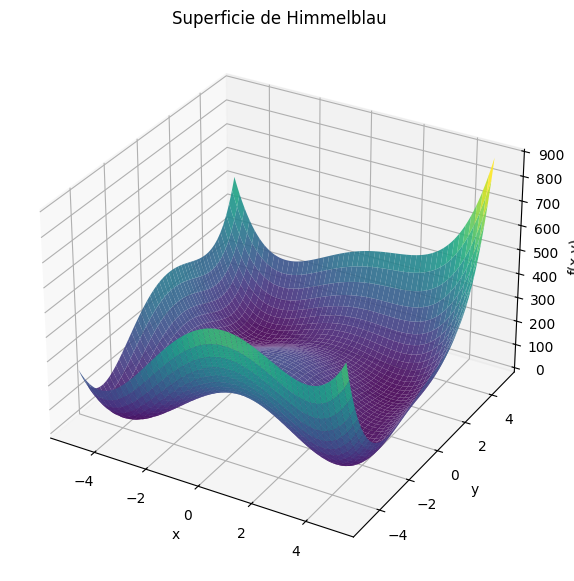

In [3]:
x_values = np.linspace(-5, 5, 350)
y_values = np.linspace(-5, 5, 350)
X, Y = np.meshgrid(x_values, y_values)
Z = objective(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, alpha=0.9)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
ax.set_title("Superficie de Himmelblau")
plt.show()

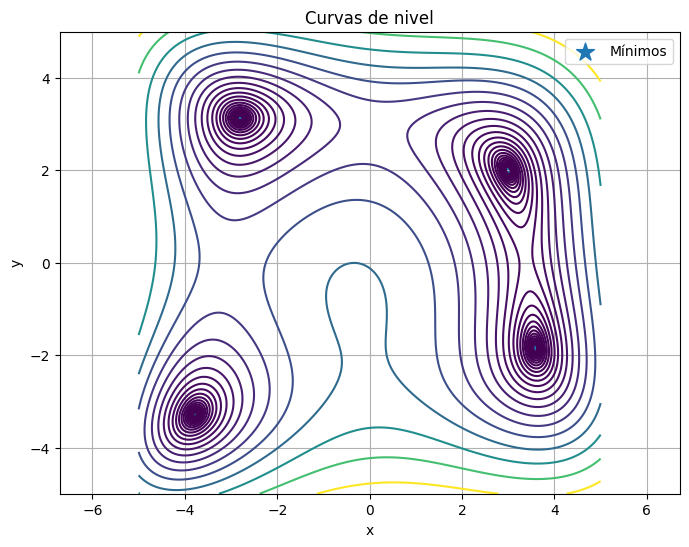

In [4]:
plt.contour(X, Y, Z, levels=np.geomspace(0.1, 500, 25), cmap="viridis")
plt.scatter(known_minima[:,0], known_minima[:,1], marker="*", s=180, label="Mínimos")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curvas de nivel")
plt.axis("equal")
plt.legend()
plt.show()

### Actividad 1

1. ¿Cuáles son las variables de decisión?
2. ¿Cuál es la función objetivo?
3. ¿El problema busca maximizar o minimizar?
4. ¿Por qué no existe una única cuenca de descenso?

## 3. Búsqueda aleatoria local

Desde un punto actual \((x_t,y_t)\), generamos una propuesta aleatoria:

$$
x'=x_t+\Delta x,
\qquad
y'=y_t+\Delta y.
$$

Aceptamos la propuesta solamente si mejora la función:

$$
f(x',y')<f(x_t,y_t).
$$

Este método no usa derivadas.

In [5]:
def random_local_search(start, step_size=0.4, iterations=300, seed=None):
    local_rng = np.random.default_rng(seed)
    current = np.array(start, dtype=float)
    current_value = objective(*current)

    path = [current.copy()]
    values = [current_value]
    accepted = [True]

    for _ in range(iterations):
        proposal = current + local_rng.normal(0, step_size, size=2)
        proposal_value = objective(*proposal)

        if proposal_value < current_value:
            current = proposal
            current_value = proposal_value
            accepted.append(True)
        else:
            accepted.append(False)

        path.append(current.copy())
        values.append(current_value)

    return np.array(path), np.array(values), np.array(accepted)

In [6]:
start = [-4, 4]
path, values, accepted = random_local_search(
    start=start,
    step_size=0.35,
    iterations=400,
    seed=7
)

print("Inicio:", path[0], "f =", values[0])
print("Final:", path[-1], "f =", values[-1])
print("Movimientos aceptados:", accepted.sum())

Inicio: [-4.  4.] f = 106.0
Final: [-2.81247196  3.12393684] f = 0.004012852163420115
Movimientos aceptados: 14


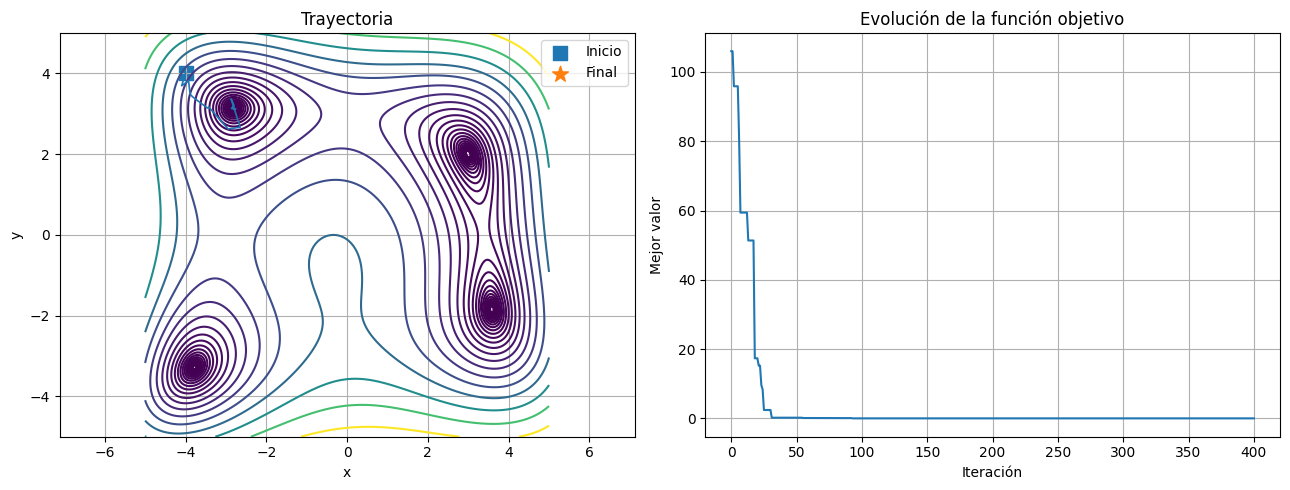

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].contour(X, Y, Z, levels=np.geomspace(0.1, 500, 25), cmap="viridis")
axes[0].plot(path[:,0], path[:,1], linewidth=1.2)
axes[0].scatter(*path[0], marker="s", s=90, label="Inicio")
axes[0].scatter(*path[-1], marker="*", s=140, label="Final")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Trayectoria")
axes[0].axis("equal")
axes[0].legend()

axes[1].plot(values)
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Mejor valor")
axes[1].set_title("Evolución de la función objetivo")

plt.tight_layout()
plt.show()

### Actividad 2

Modifica:

- el punto inicial;
- el tamaño del paso;
- el número de iteraciones;
- la semilla.

Analiza:

1. ¿La función objetivo siempre disminuye?
2. ¿La trayectoria es suave?
3. ¿El método siempre llega al mismo mínimo?
4. ¿Qué ocurre con pasos muy pequeños o muy grandes?

In [8]:
# Modifica estos valores
student_start = [0.0, 0.0]
student_step = 0.4
student_iterations = 400
student_seed = 1

student_path, student_values, _ = random_local_search(
    student_start,
    step_size=student_step,
    iterations=student_iterations,
    seed=student_seed,
)

print("Solución final:", student_path[-1])
print("Valor final:", student_values[-1])

Solución final: [3.01230513 2.03454319]
Valor final: 0.03478189027964727


## 4. Simulador interactivo

Mueve el punto inicial, cambia el tamaño del paso y ejecuta de nuevo la búsqueda.

In [9]:
x_widget = widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description="x inicial")
y_widget = widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description="y inicial")
step_widget = widgets.FloatSlider(value=0.4, min=0.05, max=1.5, step=0.05, description="Paso")
iterations_widget = widgets.IntSlider(value=400, min=20, max=1000, step=20, description="Iteraciones")
seed_widget = widgets.IntText(value=1, description="Semilla")
button = widgets.Button(description="Ejecutar", button_style="success")
output = widgets.Output()

def run_search(_):
    with output:
        clear_output(wait=True)
        path, values, accepted = random_local_search(
            [x_widget.value, y_widget.value],
            step_widget.value,
            iterations_widget.value,
            seed_widget.value,
        )

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        axes[0].contour(X, Y, Z, levels=np.geomspace(0.1, 500, 25), cmap="viridis")
        axes[0].plot(path[:,0], path[:,1], linewidth=1.2)
        axes[0].scatter(*path[0], marker="s", s=90, label="Inicio")
        axes[0].scatter(*path[-1], marker="*", s=140, label="Final")
        axes[0].scatter(known_minima[:,0], known_minima[:,1], marker="x", s=70, label="Mínimos")
        axes[0].set_title("Trayectoria")
        axes[0].axis("equal")
        axes[0].legend()

        axes[1].plot(values)
        axes[1].set_title("Mejor valor encontrado")
        axes[1].set_xlabel("Iteración")
        axes[1].set_ylabel("f(x,y)")
        plt.tight_layout()
        plt.show()

        print("Punto inicial:", path[0])
        print("Punto final:", path[-1])
        print("Valor final:", values[-1])
        print("Movimientos aceptados:", accepted.sum())

button.on_click(run_search)

display(widgets.VBox([
    widgets.HBox([x_widget, y_widget]),
    widgets.HBox([step_widget, iterations_widget]),
    widgets.HBox([seed_widget, button]),
    output,
]))

## 5. Distintos puntos iniciales

Ejecutaremos el mismo algoritmo desde varios puntos. La función y el método no cambian: solo cambia el punto inicial.

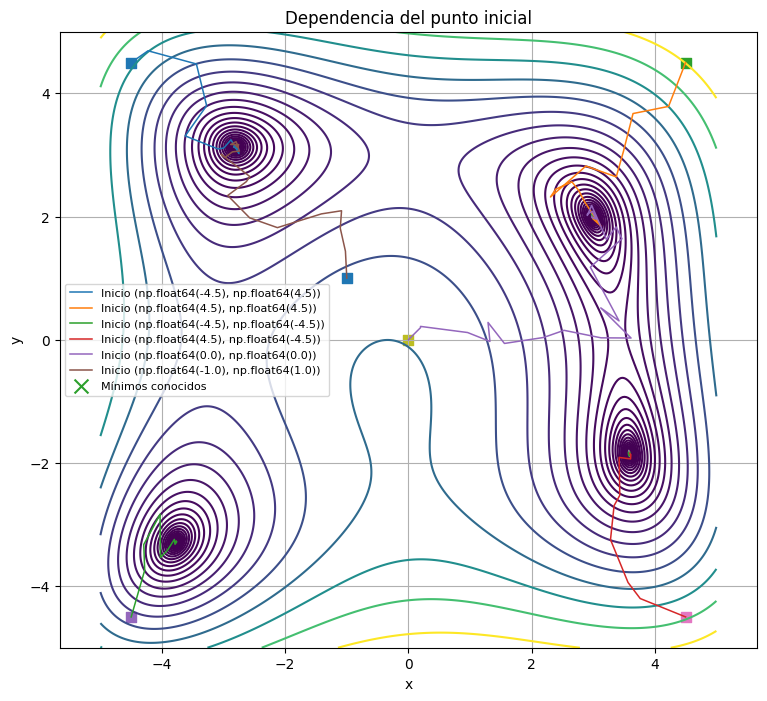

Inicio: [-4.5  4.5] -> Final: [-2.8346  3.1282] f = 0.028959
Inicio: [4.5 4.5] -> Final: [2.9935 1.9803] f = 0.010653
Inicio: [-4.5 -4.5] -> Final: [-3.775  -3.2867] f = 0.002052
Inicio: [ 4.5 -4.5] -> Final: [ 3.5913 -1.8449] f = 0.002805
Inicio: [0. 0.] -> Final: [2.9788 2.0038] f = 0.015194
Inicio: [-1.  1.] -> Final: [-2.8007  3.1478] f = 0.01175


In [10]:
initial_points = np.array([
    [-4.5, 4.5],
    [4.5, 4.5],
    [-4.5, -4.5],
    [4.5, -4.5],
    [0.0, 0.0],
    [-1.0, 1.0],
])

results = []

plt.figure(figsize=(9, 8))
plt.contour(X, Y, Z, levels=np.geomspace(0.1, 500, 25), cmap="viridis")

for i, start in enumerate(initial_points):
    path, values, _ = random_local_search(start, 0.35, 700, seed=100+i)
    results.append((start, path[-1], values[-1]))
    plt.plot(path[:,0], path[:,1], linewidth=1.1, label=f"Inicio {tuple(start)}")
    plt.scatter(*path[0], marker="s", s=50)
    plt.scatter(*path[-1], marker="*", s=110)

plt.scatter(known_minima[:,0], known_minima[:,1], marker="x", s=100, label="Mínimos conocidos")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dependencia del punto inicial")
plt.axis("equal")
plt.legend(fontsize=8)
plt.show()

for start, final, value in results:
    print("Inicio:", start, "-> Final:", np.round(final, 4), "f =", round(value, 6))

### Actividad 3

1. ¿Todos los recorridos terminan en el mismo punto?
2. ¿Todos los mínimos encontrados tienen aproximadamente el mismo valor?
3. ¿Puede una función tener varios mínimos globales?
4. ¿El algoritmo puede certificar que encontró un mínimo global?
5. Define con tus palabras una **cuenca de atracción**.

## 6. Cuencas de atracción observadas

Generaremos muchos puntos iniciales aleatorios y clasificaremos el mínimo alcanzado.

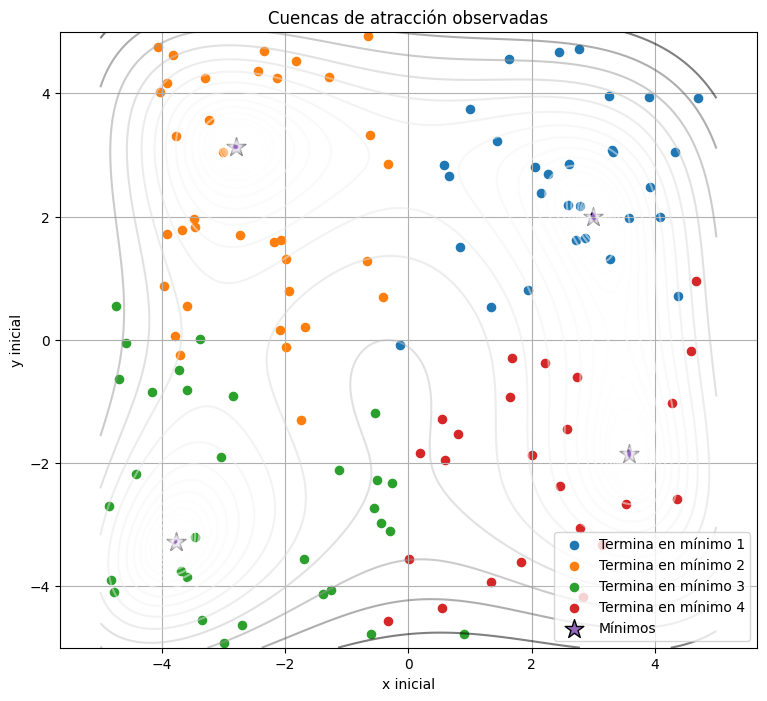

Mínimo 1: 30/120 ejecuciones
Mínimo 2: 35/120 ejecuciones
Mínimo 3: 31/120 ejecuciones
Mínimo 4: 24/120 ejecuciones


In [11]:
def nearest_minimum(point):
    distances = np.linalg.norm(known_minima - point, axis=1)
    return np.argmin(distances)

n_runs = 120
starts = rng.uniform(-5, 5, size=(n_runs, 2))
labels = []

for i, start in enumerate(starts):
    path, _, _ = random_local_search(start, 0.35, 700, seed=1000+i)
    labels.append(nearest_minimum(path[-1]))

labels = np.array(labels)

plt.figure(figsize=(9, 8))
plt.contour(X, Y, Z, levels=np.geomspace(0.1, 500, 25), cmap="Greys", alpha=0.5)

for i in range(4):
    mask = labels == i
    plt.scatter(starts[mask,0], starts[mask,1], s=35, label=f"Termina en mínimo {i+1}")

plt.scatter(known_minima[:,0], known_minima[:,1], marker="*", s=200, edgecolor="black", label="Mínimos")
plt.xlabel("x inicial")
plt.ylabel("y inicial")
plt.title("Cuencas de atracción observadas")
plt.axis("equal")
plt.legend()
plt.show()

counts = np.bincount(labels, minlength=4)
for i, count in enumerate(counts):
    print(f"Mínimo {i+1}: {count}/{n_runs} ejecuciones")

### Actividad 4

1. ¿Qué representa cada grupo de puntos?
2. ¿La cuenca observada depende únicamente de la función?
3. ¿Cómo puede cambiar al modificar el tamaño del paso?
4. ¿Qué papel desempeña la semilla aleatoria?

## 7. Comparación con una función convexa

Considera

$$
g(x,y)=x^2+2y^2.
$$

Esta función tiene un único mínimo global en \((0,0)\). En una función convexa, cualquier mínimo local es también global.

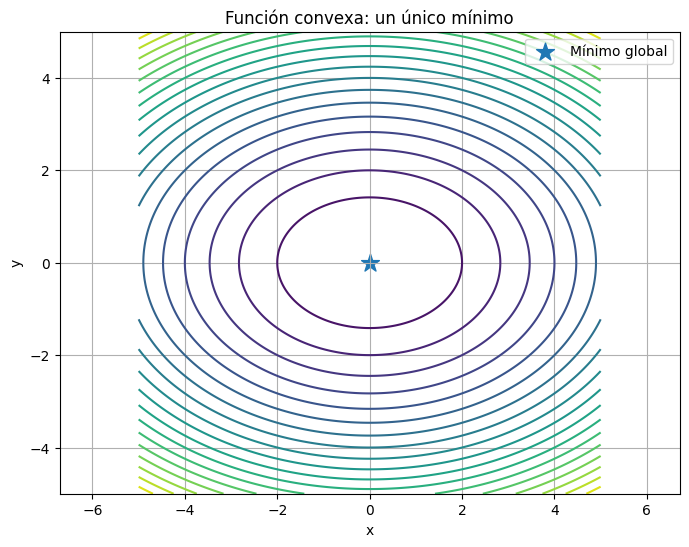

In [12]:
def convex_objective(x, y):
    return x**2 + 2*y**2

Zc = convex_objective(X, Y)

plt.contour(X, Y, Zc, levels=20, cmap="viridis")
plt.scatter([0], [0], marker="*", s=180, label="Mínimo global")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Función convexa: un único mínimo")
plt.axis("equal")
plt.legend()
plt.show()

## 8. Reto final

Estudia cómo afecta el tamaño del paso a la solución.

1. Usa al menos cuatro tamaños de paso.
2. Conserva los mismos puntos iniciales.
3. Ejecuta varias semillas.
4. Cuenta cuántas veces se alcanza cada mínimo.
5. Presenta una tabla o gráfica.
6. Escribe una conclusión.

Hipótesis para discutir:

> Un paso pequeño favorece una búsqueda muy local; uno grande permite explorar más, pero muchas propuestas son rechazadas.

In [ ]:
step_sizes = [0.1, 0.25, 0.5, 1.0]

# Desarrolla aquí el reto final.

## Conclusiones

El problema estudiado puede escribirse como

$$
\min_{x,y} f(x,y).
$$

La función de Himmelblau muestra que:

- una función no convexa puede tener varios mínimos;
- el punto inicial puede determinar la solución alcanzada;
- un método local no garantiza encontrar un mínimo global;
- la aleatoriedad y el tamaño del paso modifican el comportamiento;
- en machine learning ocurre algo similar al minimizar una pérdida respecto a los parámetros del modelo.